<a href="https://colab.research.google.com/github/laur-park/dsci235-final-project/blob/main/Diddi_Parker_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **You Are What You Can Afford: Diet, Income, and Success in College**



Lauren Parker & Isha Diddi

Professor Gaddy

DSCI 235

27 April 2026

### Introduction

Paragraph

### Part 1: Relationships Between Income, Health, Personal Beliefs, and Student Academic Performance


---



**A. Data Cleaning & Exploration**

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
data1 = pd.read_csv('cleanedfooddata.csv')
data1.head()


,GPA,Gender,breakfast,calories_chicken,calories_day,calories_scone,coffee,comfort_food,comfort_food_reasons,comfort_food_reasons_coded,...,soup,sports,thai_food,tortilla_calories,turkey_calories,type_sports,veggies_day,vitamins,waffle_calories,weight
0,3.654,1,1,610,3,420,2,"chocolate, chips, ice cream","Stress, bored, anger",1,...,1,1,2,725,690,Basketball,4,2,900,155
1,3.300,1,1,720,4,420,2,"frozen yogurt, pizza, fast food","stress, sadness",1,...,1,2,5,1165,500,none,5,1,900,I'm not answering this.
2,3.500,1,1,720,2,420,2,"Ice cream, chocolate, chips","Stress, boredom, cravings",1,...,1,1,4,940,500,Softball,4,2,760,190
3,3.800,2,1,610,3,420,2,"Chocolate, ice cream, french fries, pretzels","stress, boredom",1,...,1,1,5,940,690,soccer,4,1,1315,180
4,3.300,1,1,720,3,420,1,"Ice cream, cheeseburgers, chips.",I eat comfort food when im stressed out from s...,1,...,1,2,1,725,500,none,4,2,1315,137


In [22]:
# columns we will use: GPA (open-ended,0), (family) income (interval,32), fruit_day
# (interval,24), veggies_day (interval,51), employment (interval,14), health_feeling (interval,27)

To begin this project, our team downloaded the main dataset for part one of the project, *Cleaned Food Data*. This file was orginally an Excel sheet, so we had to convert it into a CSV file.

After examining the dataset, our team made sure to highlight and comment on which specific variables would be utilized for this project.


In [21]:
refer_to = pd.read_csv('codebook (1).csv')
refer_to = refer_to.iloc[:55, :4]
refer_to.head()

,Variables,Responses,Question,Type of Variable
0,GPA,open ended,What is your GPA?,open-ended
1,Gender,1 = Female\n2 = Male,What is your gender?,interval
2,breakfast,1 = cereal option\n2 = donut option,the participants are shown the following pictu...,interval
3,calories_chicken,open ended,guessing calories in chicken piadina,interval
4,calories_day,1 - i dont know how many calories i should con...,Importance of consuming calories per day,interval


We observed that not all variable names were specific. The lack of specificity in the variable name confused us: what does the variable truly represent? Many categorical variables also contained numerical values (e.g., 1, 2, 3), suggesting that the surveyors utilized label encoding (each category is associated with a numerical value) for their study.

We were able to obtain the codebook for *Cleaned Food Data* dataset (shown above). This dataframe describes each variable, including the survey question presented to participants, the type of variable, and how responses were encoded. This codebook helped us better understand the data we were using.



**B. Developing a relationship between family income and the likelihood of consuming fruits and vegetables.**

In [61]:
display(refer_to.iloc[31, :])
# 1 - less than $15,000
# 2 - $15,001 to $30,000
# 3 - $30,001 to $50,000
# 4 - $50,001 to $70,000
# 5 - $70,001 to $100,000
# 6 - higher than $100,000

,31
Variables,income
Responses,"1 - less than $15,000 \n2 - $15,001 to $30,000..."
Question,what is your family income?
Type of Variable,interval


In [56]:
display(refer_to.iloc[24, :])
# 1 - very unlikely
# 2 - unlikely
# 3 - neutral
# 4 - likely
# 5 - very likely

,24
Variables,fruit_day
Responses,\n1 - very unlikely \n2 - unlikely \n3 - neutr...
Question,How likely to eat fruit in a regular day
Type of Variable,interval


To test the relationship between family income and the likelihood of consuming fruits, we utilized the variables 'income' and 'fruit_day'. Both are categorical variables that utilize label encoding.

In [23]:
data1.groupby('income')['fruit_day'].mean()

,fruit_day
income,
2,5.000000
3,4.250000
4,4.333333
5,4.666667
6,4.090909


First, we calculated the mean likelihood of consuming fruit per income group. All income groups achieved a score of 4 or higher: A 4-5 score is associated with "likely"-"very likely". All income groups were atleast likely to consume a fruit in a day. It is important to notice the perfect score of 5 for income group 2 (ranging from $15,001-$30,000) came from one individual. However, there does not appear to have a direct positive or negative relationship.

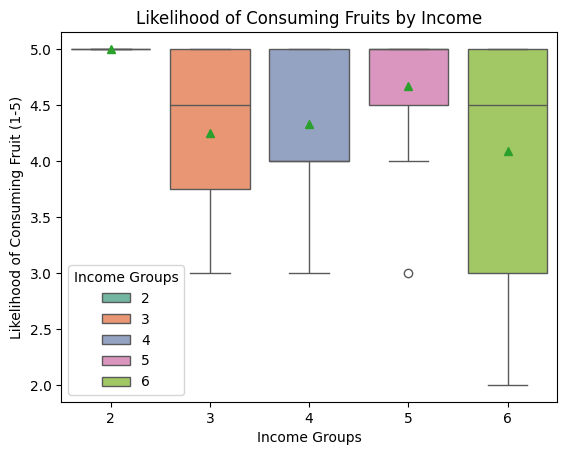

In [60]:
boxplot1 = sns.boxplot(data=data1, x='income', y='fruit_day', showmeans=True, hue='income', palette="Set2")
boxplot1.set_title('Likelihood of Consuming Fruits by Income')
boxplot1.set_ylabel('Likelihood of Consuming Fruit (1-5)')
boxplot1.set_xlabel('Income Groups')
plt.legend(title="Income Groups")


Plotting a boxplot of the likelihood of consuming fruit per income group allowed our team to visualize the variance within each group. The lack of "box" in boxplot representing income group 2 demonstrates the singular observation. There is a slight positive relationship between income groups three through five, indicating that the increase in income may correlate with a greater likelihood of consuming fruit.

In [24]:
data1.groupby('income')[['veggies_day']].mean()

,veggies_day
income,
2,5.000000
3,3.500000
4,4.222222
5,4.333333
6,3.954545


/tmp/ipykernel_37431/432878604.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  boxplot2 = sns.boxplot(data=data1, x='income', y='veggies_day', palette="Set2")


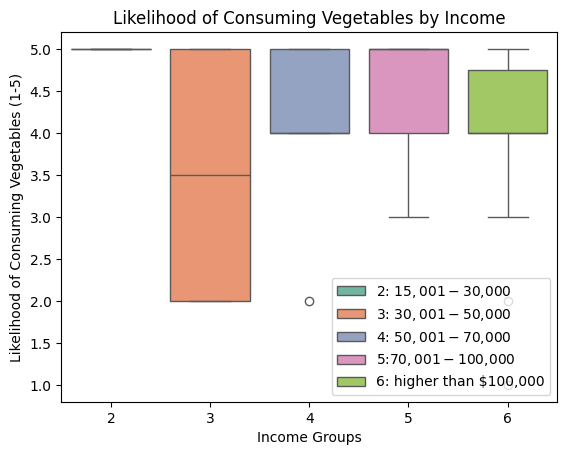

In [42]:
boxplot2 = sns.boxplot(data=data1, x='income', y='veggies_day', palette="Set2")
boxplot2.set_title('Likelihood of Consuming Vegetables by Income')
boxplot2.set_ylabel('Likelihood of Consuming Vegetables (1-5)')
boxplot2.set_xlabel('Income Groups')
plt.legend(['2: $15,001-$30,000','3: $30,001-$50,000 ','4: $50,001-$70,000', '5:$70,001-$100,000', '6: higher than $100,000'])

**C. Exploring how working status may influence a student’s likelihood to consume fruit and vegetables.**

In [40]:
data1.groupby('employment')['fruit_day'].mean()

,fruit_day
employment,
1,5.000000
2,4.142857
3,4.545455


In [41]:
data1.groupby('employment')['veggies_day'].mean()

,veggies_day
employment,
1,5.000000
2,3.892857
3,4.318182


/tmp/ipykernel_37431/65412934.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  boxplot3 = sns.boxplot(data=data1, x='employment', y='veggies_day', palette="Set2")


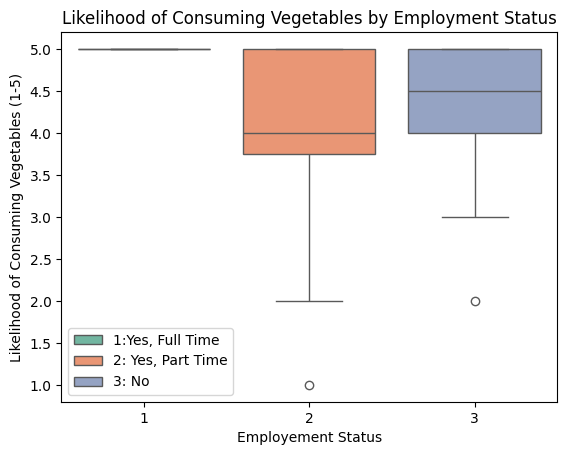

In [46]:
boxplot3 = sns.boxplot(data=data1, x='employment', y='veggies_day', palette="Set2")
boxplot3.set_title('Likelihood of Consuming Vegetables by Employment Status')
boxplot3.set_ylabel('Likelihood of Consuming Vegetables (1-5)')
boxplot3.set_xlabel('Employement Status')
plt.legend(['1:Yes, Full Time','2: Yes, Part Time', '3: No'])



/tmp/ipykernel_37431/2990425186.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  boxplot4 = sns.boxplot(data=data1, x='employment', y='fruit_day', palette="Set2")


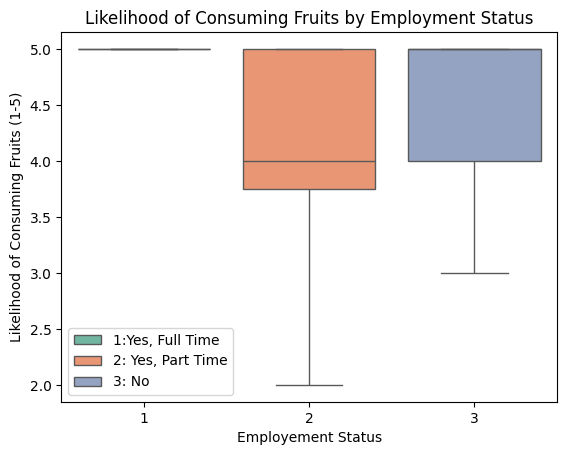

In [49]:
boxplot4 = sns.boxplot(data=data1, x='employment', y='fruit_day', palette="Set2")
boxplot4.set_title('Likelihood of Consuming Fruits by Employment Status')
boxplot4.set_ylabel('Likelihood of Consuming Fruits (1-5)')
boxplot4.set_xlabel('Employement Status')
plt.legend(['1:Yes, Full Time','2: Yes, Part Time', '3: No'])

**D. Determine whether health status and GPA are correlated.**


To quantify health status, we will be using the column health_feeling. Healthy students answered 6-10 to the question "I feel very healthy!" with 10 being "strongly agree". Unhealthy students answered 1-5 to the same question with 1 being "strongly disagree".

**E. Assess the relationship between family income and GPA.**

**F. Overall Analyses**

### Part 2: Affordability of Maintaining a Healthy Diet

---



**A. Data Cleaning & Exploration**

In [26]:
fruity = pd.read_csv('fruit-prices-2023 (2).csv')
fruity.head()

,Fruit,Form,AverageRetailPrice,AverageRetailPriceUnitOfMeasure,PreparationYieldFactor,SizeOfACupEquivalent,CupEquivalentUnitOfMeasure,AveragePricePerCupEquivalent
0,Apples,Fresh,1.860931,per pound,0.90,0.2425,pounds,0.501435
1,"Apples, applesauce",Canned,1.208099,per pound,1.00,0.5401,pounds,0.652534
2,"Apples, ready to drink",Juice,0.951115,per pint (16 fluid ounces ready to drink),1.00,0.5000,pints,0.475558
3,"Apples, frozen concentrate",Juice,2.668334,per pint (16 fluid ounces concentrate),4.00,0.5000,pints,0.333542
4,Apricots,Fresh,3.803732,per pound,0.93,0.3638,pounds,1.487802


In [27]:
veggie = pd.read_csv('vegetable-prices-2023.csv')
veggie.head()

,Vegetable,Form,AverageRetailPrice,AverageRetailPriceUnitOfMeasure,PreparationYieldFactor,SizeOfACupEquivalent,CupEquivalentUnitOfMeasure,AveragePricePerCupEquivalent
0,Acorn squash,Fresh,1.241439,per pound,0.4586,0.4519,pounds,1.223533
1,Artichoke,Fresh,2.506856,per pound,0.3750,0.3858,pounds,2.080461
2,Artichoke,Canned,3.505101,per pound,0.6500,0.3858,pounds,2.579113
3,Asparagus,Fresh,3.212453,per pound,0.4938,0.3968,pounds,2.581436
4,Asparagus,Canned,3.676296,per pound,0.6500,0.3968,pounds,2.244419


**B.  Estimating the cost per serving of fruit**

**C. Estimating the cost per serving of vegetables**

**D. Overall Analyses**

### Conclusion